# Notebook 03: Preprocessing

### English

**Purpose**

- Turn the raw, 512×512 dog/cat images validated in `01_download_data.ipynb` into a clean, model-ready dataset, using the data-quality findings from `02_eda.ipynb`.
- Remove exact- and near-duplicate images (5 exact-duplicate groups and 75 near-duplicate pairs were found in the EDA notebook, concentrated in the cat class) and near-blank/corrupted frames (one near-uniform, unreadable frame was found among the lowest-blur outliers during EDA's visual inspection).
- Produce a stratified train/validation split by species, downsample every kept image from 512×512 to the pipeline's 64×64 training resolution, and define the normalization and augmentation strategy used by `04_model_training.ipynb`.

**Data Source**

- `data/raw/manifest.csv`, produced by `01_download_data.ipynb` — 10,892 validated images (5,239 dog, 5,653 cat), all 512×512 PNG/JPG files under `data/raw/images/`. This notebook reads exclusively from the manifest and the image files it references.
- Filtering thresholds and rationale build directly on the findings of `02_eda.ipynb` (duplicate/near-duplicate hashes, blur/brightness outlier inspection); this notebook recomputes the perceptual hashes and blur statistics itself rather than depending on any intermediate file from notebook 02, so it can run standalone from the manifest alone.

**Execution Environment**

- Runs locally; GPU acceleration is not required. The most expensive step (feature extraction over all 10,892 images, and later resizing all kept images) is CPU-bound but proportional to what notebook 02 already performed once.

**Pipeline Steps**

- [ ] 1. Environment verification and dependency installation
- [ ] 2. Load manifest and configure paths
- [ ] 3. Full-dataset feature extraction (perceptual hash, grayscale std, blur variance)
- [ ] 4. Corrupted / near-blank frame detection and removal
- [ ] 5. Exact- and near-duplicate detection and removal
- [ ] 6. Consolidated filtering summary
- [ ] 7. Stratified train/validation split by species
- [ ] 8. Resize 512×512 → 64×64
- [ ] 9. Normalization strategy ([-1, 1] range for tanh-based Generator output)
- [ ] 10. Data augmentation strategy (preview only; applied on-the-fly during training)
- [ ] 11. Process and export all kept images and manifests
- [ ] 12. Final sanity checks
- [ ] 13. Summary

---

### Tiếng Việt

**Mục tiêu**

- Chuyển tập ảnh chó/mèo gốc 512×512 đã được kiểm tra hợp lệ ở `01_download_data.ipynb` thành một tập dữ liệu sạch, sẵn sàng cho huấn luyện, dựa trên các phát hiện về chất lượng dữ liệu từ `02_eda.ipynb`.
- Loại bỏ ảnh trùng lặp chính xác và trùng lặp gần (EDA đã tìm thấy 5 nhóm trùng lặp chính xác và 75 cặp trùng lặp gần, tập trung chủ yếu ở lớp mèo) và các khung hình gần như trống/hỏng (EDA phát hiện một ảnh gần như đồng màu, không đọc được nội dung, nằm trong nhóm outlier có độ mờ thấp nhất khi kiểm tra trực quan).
- Tạo tập train/validation phân tầng theo loài, resize toàn bộ ảnh được giữ lại từ 512×512 xuống độ phân giải huấn luyện 64×64 của pipeline, và xác định chiến lược chuẩn hóa cũng như augmentation sử dụng ở `04_model_training.ipynb`.

**Nguồn dữ liệu**

- `data/raw/manifest.csv`, được tạo bởi `01_download_data.ipynb` — 10.892 ảnh đã qua kiểm tra hợp lệ (5.239 chó, 5.653 mèo), toàn bộ là file PNG/JPG 512×512 trong `data/raw/images/`. Notebook này chỉ đọc từ manifest và các file ảnh mà nó tham chiếu.
- Các ngưỡng lọc và lý do lựa chọn dựa trực tiếp trên các phát hiện của `02_eda.ipynb` (hash trùng lặp/trùng lặp gần, kiểm tra trực quan outlier độ mờ/độ sáng); notebook này tự tính lại perceptual hash và thống kê độ mờ thay vì phụ thuộc vào file trung gian nào từ notebook 02, để có thể chạy độc lập chỉ từ manifest.

**Môi trường thực thi**

- Chạy trên máy cục bộ (local); không yêu cầu GPU. Bước tốn chi phí nhất (trích xuất đặc trưng trên toàn bộ 10.892 ảnh, và sau đó resize toàn bộ ảnh được giữ lại) là CPU-bound nhưng tương đương với những gì notebook 02 đã thực hiện một lần.

**Các bước trong pipeline**

- [ ] 1. Kiểm tra môi trường và cài đặt thư viện phụ thuộc
- [ ] 2. Tải manifest và thiết lập đường dẫn
- [ ] 3. Trích xuất đặc trưng trên toàn bộ dataset (perceptual hash, độ lệch chuẩn grayscale, blur variance)
- [ ] 4. Phát hiện và loại bỏ khung hình hỏng / gần như trống
- [ ] 5. Phát hiện và loại bỏ ảnh trùng lặp chính xác và trùng lặp gần
- [ ] 6. Tổng hợp kết quả lọc dữ liệu
- [ ] 7. Chia tập train/validation phân tầng theo loài
- [ ] 8. Resize 512×512 → 64×64
- [ ] 9. Chiến lược chuẩn hóa (khoảng [-1, 1] cho đầu ra tanh của Generator)
- [ ] 10. Chiến lược augmentation (chỉ minh họa; áp dụng động lúc huấn luyện)
- [ ] 11. Xử lý và xuất toàn bộ ảnh được giữ lại cùng các manifest
- [ ] 12. Kiểm tra hợp lý cuối cùng
- [ ] 13. Tổng kết


## 1. Environment Verification and Dependency Installation

### English

**Objective**

- Confirm that the Python packages required for this notebook are available.
- Automatically install any missing dependency.

---

### Tiếng Việt

**Mục tiêu**

- Xác nhận các thư viện Python cần thiết cho notebook đã sẵn sàng.
- Tự động cài đặt các thư viện còn thiếu.


In [1]:
import importlib
import subprocess
import sys

REQUIRED = ["cv2", "PIL", "pandas", "numpy", "matplotlib", "imagehash", "scipy", "sklearn", "tqdm"]
PIP_NAMES = {"cv2": "opencv-python", "PIL": "pillow", "sklearn": "scikit-learn"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAMES.get(mod, mod))

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("All required packages are already installed.")


All required packages are already installed.


## 2. Load Manifest and Configure Paths

### English

**Objective**

- Load `data/raw/manifest.csv` and confirm it matches the state left by notebook 01.
- Define the output locations for this notebook: processed images (`data/processed/images_64/`), split manifests, the removal log, and figures (`reports/figures/03_preprocessing_64/`).

---

### Tiếng Việt

**Mục tiêu**

- Tải `data/raw/manifest.csv` và xác nhận nó khớp với trạng thái để lại từ notebook 01.
- Xác định các vị trí đầu ra của notebook này: ảnh đã xử lý (`data/processed/images_64/`), các manifest chia tập, log ảnh bị loại, và thư mục biểu đồ (`reports/figures/03_preprocessing_64/`).


**64×64 safety/versioning note**

This notebook intentionally keeps the 64×64 preprocessing run separate from the legacy 128×128 artifacts:

- Images: `data/processed/images_64/`
- Train manifest: `data/processed/train_manifest_64.csv`
- Validation manifest: `data/processed/val_manifest_64.csv`
- Removal log: `data/processed/removed_images_log_64.csv`
- Figures: `reports/figures/03_preprocessing_64/`

Running this notebook will therefore not overwrite the legacy 128×128 manifests, processed-image directory, or preprocessing figures.

---

**Ghi chú an toàn/versioning cho bản 64×64**

Notebook này cố ý tách toàn bộ kết quả preprocessing 64×64 khỏi bản 128×128 cũ:

- Ảnh: `data/processed/images_64/`
- Train manifest: `data/processed/train_manifest_64.csv`
- Validation manifest: `data/processed/val_manifest_64.csv`
- Log ảnh bị loại: `data/processed/removed_images_log_64.csv`
- Biểu đồ: `reports/figures/03_preprocessing_64/`

Vì vậy chạy notebook này sẽ không ghi đè các manifest, thư mục ảnh đã xử lý hoặc biểu đồ preprocessing của bản 128×128 cũ.

---


In [2]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
IMAGES_64_DIR = DATA_PROCESSED / "images_64"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "03_preprocessing_64"

IMAGES_64_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(DATA_RAW / "manifest.csv")
manifest = manifest[manifest["is_valid"]].reset_index(drop=True)

print(f"Project root      : {PROJECT_ROOT}")
print(f"Processed images  : {IMAGES_64_DIR}")
print(f"Figures dir        : {FIGURES_DIR}")
print(f"Manifest rows      : {len(manifest)}")
print(manifest["species"].value_counts())


Project root      : d:\Images by GAN\dog-gan-project
Processed images  : d:\Images by GAN\dog-gan-project\data\processed\images_64
Figures dir        : d:\Images by GAN\dog-gan-project\reports\figures\03_preprocessing_64
Manifest rows      : 10892
species
cat    5653
dog    5239
Name: count, dtype: int64


## 3. Full-Dataset Feature Extraction

### English

**Objective**

- Compute, for every image in the manifest, the three statistics needed to filter the dataset: a perceptual hash (for duplicate detection), the grayscale pixel standard deviation, and the Laplacian blur variance (both used for corrupted/near-blank frame detection, and blur variance additionally used as a quality tie-breaker among duplicates).

**Notes**

- These are the same statistics computed in `02_eda.ipynb`; they are recomputed here (rather than loaded from a saved file) so this notebook can run standalone from the manifest alone.

---

### Tiếng Việt

**Mục tiêu**

- Tính, cho mỗi ảnh trong manifest, ba thống kê cần thiết để lọc dữ liệu: perceptual hash (dùng để phát hiện trùng lặp), độ lệch chuẩn pixel grayscale, và Laplacian blur variance (cả hai dùng để phát hiện khung hình hỏng/gần như trống, và blur variance còn được dùng làm tiêu chí phân xử chất lượng giữa các ảnh trùng lặp).

**Lưu ý**

- Đây là các thống kê tương tự đã tính ở `02_eda.ipynb`; chúng được tính lại ở đây (thay vì tải từ file đã lưu) để notebook này có thể chạy độc lập chỉ từ manifest.


In [3]:
import cv2
import numpy as np
from PIL import Image
import imagehash
from tqdm.auto import tqdm

records = []
for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="Extracting features"):
    img_path = PROJECT_ROOT / row["filepath"]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    gray_std = float(gray.std())
    blur_var = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    phash = str(imagehash.phash(Image.fromarray(img_rgb)))

    records.append({
        "filepath": row["filepath"],
        "species": row["species"],
        "gray_std": gray_std,
        "blur_var": blur_var,
        "phash": phash,
    })

features = pd.DataFrame(records)
features["removal_reason"] = None  # filled in by sections 4 and 5
print(f"Extracted features for {len(features)} images.")
features.describe(include="all")


Extracting features:   0%|          | 0/10892 [00:00<?, ?it/s]

Extracted features for 10892 images.


,filepath,species,gray_std,blur_var,phash,removal_reason
count,10892,10892,10892.000000,10892.000000,10892,0
unique,10892,2,NaN,NaN,10887,0
top,data\raw\images\dog_05238_pixabay_dog_004058.jpg,cat,NaN,NaN,807cb79c9d8c1d39,NaN
freq,1,5653,NaN,NaN,2,NaN
mean,NaN,NaN,57.189384,1457.463654,NaN,NaN
std,NaN,NaN,12.822419,2188.735385,NaN,NaN
min,NaN,NaN,6.189519,7.862930,NaN,NaN
25%,NaN,NaN,48.236812,286.253941,NaN,NaN
50%,NaN,NaN,56.466920,713.640527,NaN,NaN
75%,NaN,NaN,65.332638,1713.922008,NaN,NaN


## 4. Corrupted / Near-Blank Frame Detection and Removal

### English

**Objective**

- Flag and remove frames that are essentially unreadable — near-uniform in color with almost no internal structure — rather than genuinely soft-focus but valid photographs.
- Motivated directly by `02_eda.ipynb`'s outlier inspection, which visually confirmed that one of the lowest-blur-variance images in the dataset is a near-solid dark frame with no recognizable animal, while the rest of the low-blur and brightness-extreme outliers were genuine (if unusual) photographs.

**Notes**

- A single low-blur threshold is deliberately avoided, since it would also exclude legitimately soft, low-detail photographs (which still have normal tonal variation). Instead, two conditions are required **simultaneously**: a very low grayscale standard deviation (near-uniform pixel values — `gray_std < GRAY_STD_THRESHOLD`) **and** a very low blur variance (`blur_var < BLUR_VAR_THRESHOLD`). A genuinely blurry but valid photo still varies substantially in intensity (shadows, fur color, background); a broken/blank frame does not.
- Thresholds are intentionally conservative (aiming to catch only clearly degenerate frames, not merely soft photographs); the flagged set is inspected visually below before being finalized.

**Output**

- A grid of every flagged image, for visual confirmation.

---

### Tiếng Việt

**Mục tiêu**

- Đánh dấu và loại bỏ các khung hình về cơ bản không đọc được — gần như đồng màu, hầu như không có cấu trúc nội dung — chứ không phải các ảnh mờ nhưng vẫn hợp lệ.
- Xuất phát trực tiếp từ phần kiểm tra outlier ở `02_eda.ipynb`, đã xác nhận bằng mắt rằng một trong những ảnh có blur variance thấp nhất tập dữ liệu là một khung hình gần như đồng màu tối, không nhận diện được con vật nào, trong khi các outlier độ mờ/độ sáng cực đoan còn lại đều là ảnh thật (dù bất thường).

**Lưu ý**

- Cố tình không dùng một ngưỡng blur duy nhất, vì nó sẽ loại luôn cả những ảnh mờ nhưng hợp lệ (vẫn có biến động màu sắc bình thường). Thay vào đó, cần **đồng thời** hai điều kiện: độ lệch chuẩn grayscale rất thấp (giá trị pixel gần như đồng nhất — `gray_std < GRAY_STD_THRESHOLD`) **và** blur variance rất thấp (`blur_var < BLUR_VAR_THRESHOLD`). Một ảnh mờ nhưng hợp lệ vẫn có biến động cường độ đáng kể (bóng đổ, màu lông, nền); một khung hình hỏng/trống thì không.
- Các ngưỡng được chọn có chủ đích thận trọng (chỉ nhằm bắt các khung hình hỏng rõ ràng, không loại nhầm ảnh chỉ đơn thuần mờ); tập ảnh bị đánh dấu được kiểm tra trực quan bên dưới trước khi chốt.

**Kết quả**

- Lưới hiển thị toàn bộ ảnh bị đánh dấu, để xác nhận bằng mắt.


In [4]:
GRAY_STD_THRESHOLD = 10.0
BLUR_VAR_THRESHOLD = 50.0

corrupted_mask = (features["gray_std"] < GRAY_STD_THRESHOLD) & (features["blur_var"] < BLUR_VAR_THRESHOLD)
corrupted_candidates = features[corrupted_mask]

print(f"Flagged {len(corrupted_candidates)} near-blank / corrupted candidate(s):")
print(corrupted_candidates[["filepath", "species", "gray_std", "blur_var"]])


Flagged 1 near-blank / corrupted candidate(s):
                                              filepath species  gray_std  \
1876  data\raw\images\cat_01876_pixabay_cat_001267.jpg     cat  6.189519   

      blur_var  
1876   7.86293  


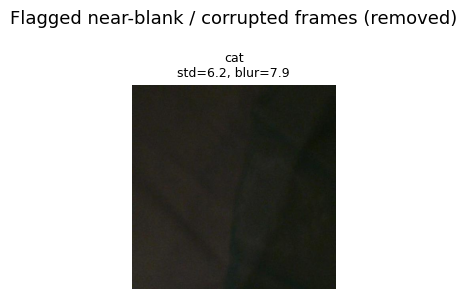

Marked 1 image(s) for removal (reason: corrupted_or_blank).


In [5]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage

n_flagged = len(corrupted_candidates)

if n_flagged == 0:
    print("No near-blank / corrupted frames flagged — nothing to visualize.")
else:
    n_cols = min(6, n_flagged)
    n_rows = int(np.ceil(n_flagged / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, corrupted_candidates.iterrows()):
        img = PILImage.open(PROJECT_ROOT / row["filepath"])
        ax.imshow(img)
        ax.set_title(f"{row['species']}\nstd={row['gray_std']:.1f}, blur={row['blur_var']:.1f}", fontsize=9)
        ax.axis("off")
    for ax in axes[n_flagged:]:
        ax.axis("off")

    fig.suptitle("Flagged near-blank / corrupted frames (removed)", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "01_corrupted_frames_removed.png", dpi=150)
    plt.show()

features.loc[corrupted_mask, "removal_reason"] = "corrupted_or_blank"
print(f"Marked {corrupted_mask.sum()} image(s) for removal (reason: corrupted_or_blank).")


## 5. Exact- and Near-Duplicate Detection and Removal

### English

**Objective**

- Among the images that survived Section 4 (not flagged as corrupted/blank), find groups of exact- and near-duplicate images using perceptual hashing, and keep only one representative per group.
- Matches the method used in `02_eda.ipynb`: exact duplicates share an identical 64-bit perceptual hash; near-duplicates have a Hamming distance of at most 5 bits, compared only within the same species (a dog and a cat are never considered duplicates of each other).

**Notes**

- Duplicate groups are found via a union-find (connected-components) pass, so that a chain of near-duplicates (A~B, B~C) is grouped together even if A and C are not directly within the threshold of each other.
- Within each group, the image with the **highest blur variance** (sharpest) is kept as the representative, and the rest are marked for removal — a simple, defensible quality heuristic when multiple near-identical copies exist.
- EDA found duplication concentrated almost entirely in the cat class (all 5 exact-duplicate groups were cat images; 60 of 75 near-duplicate pairs were cat), so the cat class is expected to lose more images here.

**Output**

- A few example duplicate/near-duplicate groups, showing the kept image next to the removed one(s).

---

### Tiếng Việt

**Mục tiêu**

- Trong số các ảnh đã qua được Mục 4 (không bị đánh dấu là hỏng/trống), tìm các nhóm ảnh trùng lặp chính xác và trùng lặp gần bằng perceptual hashing, và chỉ giữ lại một ảnh đại diện cho mỗi nhóm.
- Áp dụng đúng phương pháp đã dùng ở `02_eda.ipynb`: trùng lặp chính xác có perceptual hash 64-bit giống hệt nhau; trùng lặp gần có khoảng cách Hamming tối đa 5 bit, chỉ so sánh trong cùng một loài (chó và mèo không bao giờ được coi là trùng lặp của nhau).

**Lưu ý**

- Các nhóm trùng lặp được tìm bằng thuật toán union-find (connected-components), để một chuỗi trùng lặp gần (A~B, B~C) được gom vào cùng nhóm dù A và C không trực tiếp nằm trong ngưỡng của nhau.
- Trong mỗi nhóm, ảnh có **blur variance cao nhất** (sắc nét nhất) được giữ lại làm đại diện, các ảnh còn lại bị đánh dấu loại bỏ — một tiêu chí chất lượng đơn giản, hợp lý khi có nhiều bản gần giống nhau.
- EDA cho thấy trùng lặp tập trung gần như hoàn toàn ở lớp mèo (cả 5 nhóm trùng lặp chính xác đều là ảnh mèo; 60/75 cặp trùng lặp gần là mèo), nên lớp mèo dự kiến sẽ mất nhiều ảnh hơn ở bước này.

**Kết quả**

- Một vài nhóm trùng lặp/trùng lặp gần ví dụ, hiển thị ảnh được giữ lại cạnh (các) ảnh bị loại bỏ.


In [6]:
from scipy.spatial.distance import pdist, squareform

NEAR_DUP_THRESHOLD = 5  # max Hamming distance (bits) to count as a near-duplicate

def hash_to_bits(hash_str, n_bits=64):
    return np.array([int(b) for b in bin(int(hash_str, 16))[2:].zfill(n_bits)], dtype=np.uint8)

survivors = features[features["removal_reason"].isna()].reset_index(drop=True)

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[ra] = rb

duplicate_group_id = np.full(len(survivors), -1, dtype=int)
next_group_id = 0

for species, group in survivors.groupby("species"):
    idx = group.index.to_numpy()
    bit_matrix = np.stack([hash_to_bits(h) for h in group["phash"]])
    distances = squareform(pdist(bit_matrix, metric="hamming") * bit_matrix.shape[1])
    uf = UnionFind(len(idx))
    close_pairs = np.argwhere(np.triu(distances <= NEAR_DUP_THRESHOLD, k=1))
    for i, j in close_pairs:
        uf.union(int(i), int(j))

    local_groups = {}
    for local_i, global_i in enumerate(idx):
        root = uf.find(local_i)
        local_groups.setdefault(root, []).append(global_i)

    for members in local_groups.values():
        if len(members) > 1:
            for m in members:
                duplicate_group_id[survivors.index.get_loc(m)] = next_group_id
            next_group_id += 1

survivors["duplicate_group_id"] = duplicate_group_id
n_groups = next_group_id
n_in_groups = int((duplicate_group_id >= 0).sum())
print(f"Found {n_groups} duplicate/near-duplicate group(s) covering {n_in_groups} image(s).")
print(survivors[survivors['duplicate_group_id'] >= 0].groupby('species').size())


Found 75 duplicate/near-duplicate group(s) covering 150 image(s).
species
cat    120
dog     30
dtype: int64


In [7]:
dup_removal_indices = []

for group_id, group_df in survivors[survivors["duplicate_group_id"] >= 0].groupby("duplicate_group_id"):
    keep_idx = group_df["blur_var"].idxmax()  # sharpest image in the group is kept
    drop_idx = [i for i in group_df.index if i != keep_idx]
    dup_removal_indices.extend(drop_idx)

dup_removal_filepaths = set(survivors.loc[dup_removal_indices, "filepath"])
features.loc[features["filepath"].isin(dup_removal_filepaths), "removal_reason"] = "duplicate"

print(f"Marked {len(dup_removal_filepaths)} image(s) for removal (reason: duplicate).")


Marked 75 image(s) for removal (reason: duplicate).


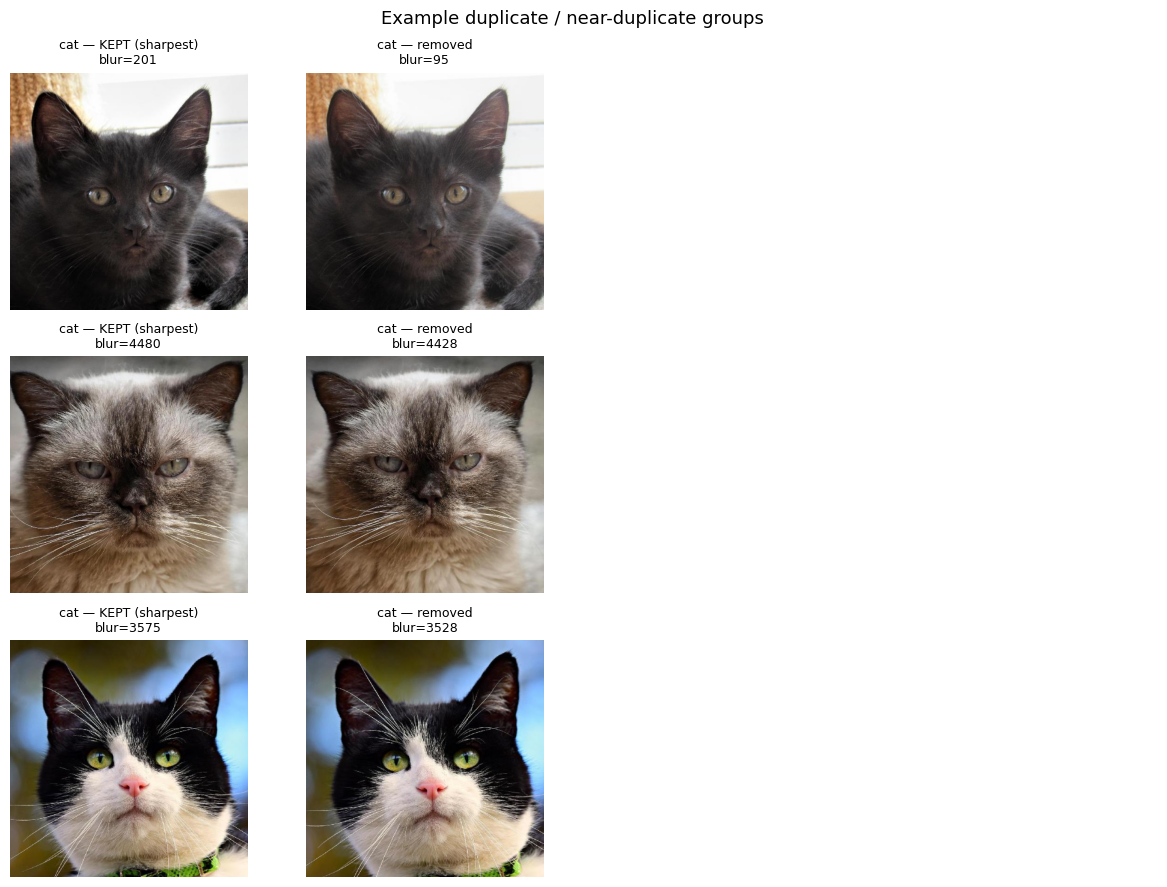

In [8]:
example_group_ids = survivors.loc[survivors["duplicate_group_id"] >= 0, "duplicate_group_id"].unique()[:3]

if len(example_group_ids) == 0:
    print("No duplicate groups found — nothing to visualize.")
else:
    fig, axes = plt.subplots(len(example_group_ids), 4, figsize=(12, 3 * len(example_group_ids)))
    axes = np.atleast_2d(axes)

    for row_i, group_id in enumerate(example_group_ids):
        members = survivors[survivors["duplicate_group_id"] == group_id].sort_values("blur_var", ascending=False)
        for col_i in range(4):
            ax = axes[row_i, col_i]
            if col_i < len(members):
                m = members.iloc[col_i]
                img = PILImage.open(PROJECT_ROOT / m["filepath"])
                ax.imshow(img)
                status = "KEPT (sharpest)" if col_i == 0 else "removed"
                ax.set_title(f"{m['species']} — {status}\nblur={m['blur_var']:.0f}", fontsize=9)
            ax.axis("off")

    fig.suptitle("Example duplicate / near-duplicate groups", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "02_duplicate_groups_examples.png", dpi=150)
    plt.show()


## 6. Consolidated Filtering Summary

### English

**Objective**

- Summarize how many images were removed, broken down by reason (corrupted/blank vs. duplicate) and by species, and confirm the resulting class balance is still close to even.

**Output**

- A bar chart of removed-image counts by reason and species.
- Before/after class balance counts.

---

### Tiếng Việt

**Mục tiêu**

- Tổng hợp số lượng ảnh bị loại bỏ, phân theo lý do (hỏng/trống so với trùng lặp) và theo loài, đồng thời xác nhận cân bằng lớp sau khi lọc vẫn gần như đồng đều.

**Kết quả**

- Biểu đồ cột số ảnh bị loại theo lý do và theo loài.
- Số lượng theo lớp trước/sau khi lọc.


In [9]:
removal_counts = features[features["removal_reason"].notna()].groupby(["species", "removal_reason"]).size().unstack(fill_value=0)
print("Removed images by species and reason:")
print(removal_counts)

clean_manifest = manifest.merge(
    features[["filepath", "removal_reason"]], on="filepath", how="left"
)
clean_manifest = clean_manifest[clean_manifest["removal_reason"].isna()].drop(columns=["removal_reason"]).reset_index(drop=True)

print("\nBefore filtering:")
print(manifest["species"].value_counts())
print("\nAfter filtering:")
print(clean_manifest["species"].value_counts())
print(f"\nTotal removed: {len(manifest) - len(clean_manifest)} / {len(manifest)}")


Removed images by species and reason:
removal_reason  corrupted_or_blank  duplicate
species                                      
cat                              1         60
dog                              0         15

Before filtering:
species
cat    5653
dog    5239
Name: count, dtype: int64

After filtering:
species
cat    5592
dog    5224
Name: count, dtype: int64

Total removed: 76 / 10892


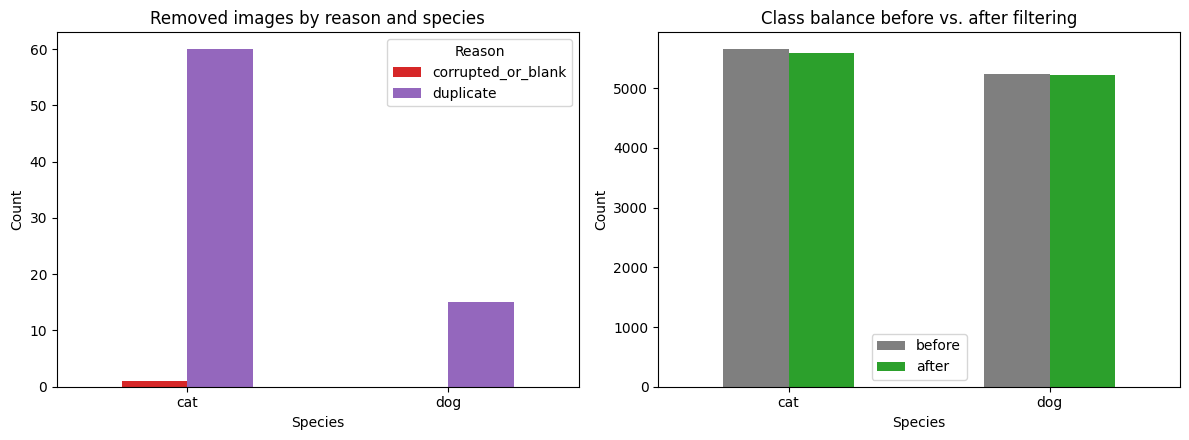

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

removal_counts.plot(kind="bar", ax=axes[0], color=["#d62728", "#9467bd"])
axes[0].set_title("Removed images by reason and species")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Count")
axes[0].legend(title="Reason")
axes[0].tick_params(axis="x", rotation=0)

before_after = pd.DataFrame({
    "before": manifest["species"].value_counts(),
    "after": clean_manifest["species"].value_counts(),
})
before_after.plot(kind="bar", ax=axes[1], color=["#7f7f7f", "#2ca02c"])
axes[1].set_title("Class balance before vs. after filtering")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_filtering_summary.png", dpi=150)
plt.show()


## 7. Stratified Train/Validation Split by Species

### English

**Objective**

- Split the cleaned manifest into training and validation sets, stratified by species so both sets preserve the overall class balance.
- The validation set is intentionally small (8%): unlike supervised learning, GAN training has no "predict on unseen labels" objective, so a large held-out set is not required for model selection. Its purpose here is narrower — providing real, never-trained-on images for the memorization check planned in `05_evaluation_report.ipynb` (comparing generated samples against genuinely unseen real photos to detect the Generator reproducing training images).

**Output**

- Row counts per split and species.

---

### Tiếng Việt

**Mục tiêu**

- Chia manifest đã làm sạch thành tập train và validation, phân tầng theo loài để cả hai tập đều giữ đúng tỉ lệ cân bằng lớp tổng thể.
- Tập validation được chọn nhỏ (8%) một cách có chủ đích: khác với học có giám sát, huấn luyện GAN không có mục tiêu "dự đoán trên nhãn chưa thấy", nên không cần một tập giữ lại lớn để chọn mô hình. Vai trò của nó ở đây hẹp hơn — cung cấp ảnh thật, chưa từng dùng để huấn luyện, phục vụ kiểm tra memorization dự kiến ở `05_evaluation_report.ipynb` (so sánh ảnh do model sinh ra với ảnh thật chưa từng thấy để phát hiện việc Generator "học thuộc lòng" ảnh huấn luyện).

**Kết quả**

- Số lượng ảnh theo từng tập và từng loài.


In [11]:
from sklearn.model_selection import train_test_split

VAL_FRACTION = 0.08
RANDOM_SEED = 42

train_df, val_df = train_test_split(
    clean_manifest,
    test_size=VAL_FRACTION,
    stratify=clean_manifest["species"],
    random_state=RANDOM_SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)} images")
print(train_df["species"].value_counts())
print(f"\nValidation: {len(val_df)} images")
print(val_df["species"].value_counts())


Train: 9950 images
species
cat    5144
dog    4806
Name: count, dtype: int64

Validation: 866 images
species
cat    448
dog    418
Name: count, dtype: int64


## 8. Resize 512×512 → 64×64

### English

**Objective**

- Downsample every kept image from the source 512×512 resolution to 64×64, the resolution `04_model_training.ipynb` trains at.
- Use `cv2.INTER_AREA` interpolation, the interpolation OpenCV recommends specifically for shrinking images, since it averages over pixel areas rather than picking/interpolating single points and so avoids aliasing artifacts that nearest-neighbor or bilinear downsampling can introduce.

**Output**

- A side-by-side comparison of a few images at 512×512 (original) and 64×64 (resized), one pair per species.

---

### Tiếng Việt

**Mục tiêu**

- Giảm kích thước mọi ảnh được giữ lại từ độ phân giải gốc 512×512 xuống 64×64, độ phân giải mà `04_model_training.ipynb` dùng để huấn luyện.
- Dùng phép nội suy `cv2.INTER_AREA`, phép nội suy OpenCV khuyến nghị riêng cho việc thu nhỏ ảnh, vì nó lấy trung bình trên vùng pixel thay vì chọn/nội suy từng điểm đơn lẻ, nhờ đó tránh được hiện tượng răng cưa (aliasing) mà nearest-neighbor hay bilinear có thể gây ra khi thu nhỏ.

**Kết quả**

- So sánh trực quan một vài ảnh ở 512×512 (gốc) và 64×64 (đã resize), một cặp cho mỗi loài.


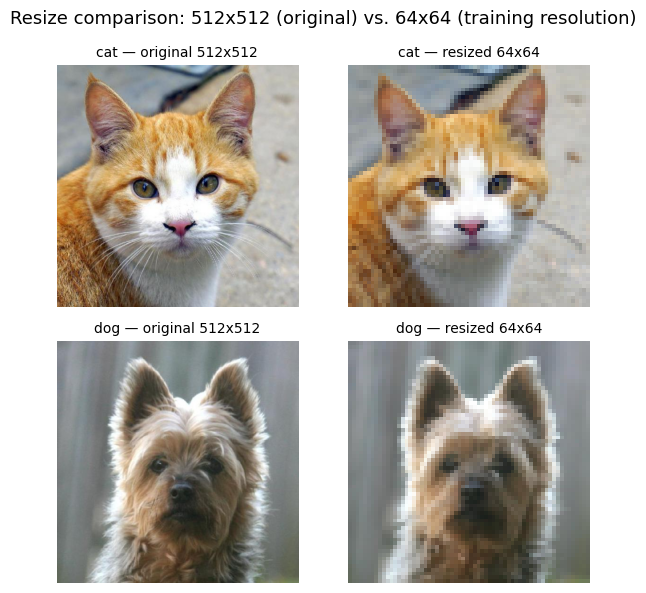

In [12]:
TARGET_SIZE = (64, 64)

def load_and_resize(filepath, target_size=TARGET_SIZE):
    img_bgr = cv2.imread(str(PROJECT_ROOT / filepath))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_AREA)
    return img_rgb, resized

sample_rows = pd.concat([
    train_df[train_df["species"] == sp].sample(1, random_state=RANDOM_SEED)
    for sp in sorted(train_df["species"].unique())
]).reset_index(drop=True)

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(6, 3 * len(sample_rows)))
axes = np.atleast_2d(axes)

for i, row in sample_rows.iterrows():
    original, resized = load_and_resize(row["filepath"])
    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"{row['species']} — original {original.shape[1]}x{original.shape[0]}", fontsize=10)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(resized)
    axes[i, 1].set_title(f"{row['species']} — resized {resized.shape[1]}x{resized.shape[0]}", fontsize=10)
    axes[i, 1].axis("off")

fig.suptitle("Resize comparison: 512x512 (original) vs. 64x64 (training resolution)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_resize_comparison.png", dpi=150)
plt.show()


## 9. Normalization Strategy

### English

**Objective**

- Define the pixel-value normalization used at training time: scaling from `[0, 255]` (`uint8`) to `[-1, 1]` (`float32`), the standard range for a DCGAN Generator with a `tanh` output activation.
- Images are kept as standard 8-bit PNGs on disk (Section 11); normalization is applied on-the-fly when a batch is loaded in `04_model_training.ipynb`, rather than baked into the saved files, since `[-1, 1]` float data cannot be stored losslessly as a standard image format and keeping raw 8-bit files on disk is both smaller and reusable if the normalization range ever changes.

**Output**

- The normalize/denormalize functions, demonstrated on one image, with a pixel-value histogram before and after.

---

### Tiếng Việt

**Mục tiêu**

- Xác định cách chuẩn hóa giá trị pixel dùng lúc huấn luyện: co giãn từ `[0, 255]` (`uint8`) sang `[-1, 1]` (`float32`), khoảng giá trị chuẩn cho Generator của DCGAN có hàm kích hoạt đầu ra `tanh`.
- Ảnh trên đĩa vẫn được giữ ở định dạng PNG 8-bit chuẩn (Mục 11); việc chuẩn hóa được áp dụng động khi tải từng batch ở `04_model_training.ipynb`, thay vì lưu cố định vào file, vì dữ liệu float `[-1, 1]` không thể lưu không mất mát dưới định dạng ảnh thông thường, và giữ file 8-bit thô trên đĩa vừa nhẹ hơn vừa dễ tái sử dụng nếu khoảng chuẩn hóa thay đổi sau này.

**Kết quả**

- Hàm normalize/denormalize, minh họa trên một ảnh, kèm histogram giá trị pixel trước và sau.


Original dtype/range   : uint8, [12, 255]
Normalized dtype/range : float32, [-0.906, 1.000]
Round-trip matches original: True


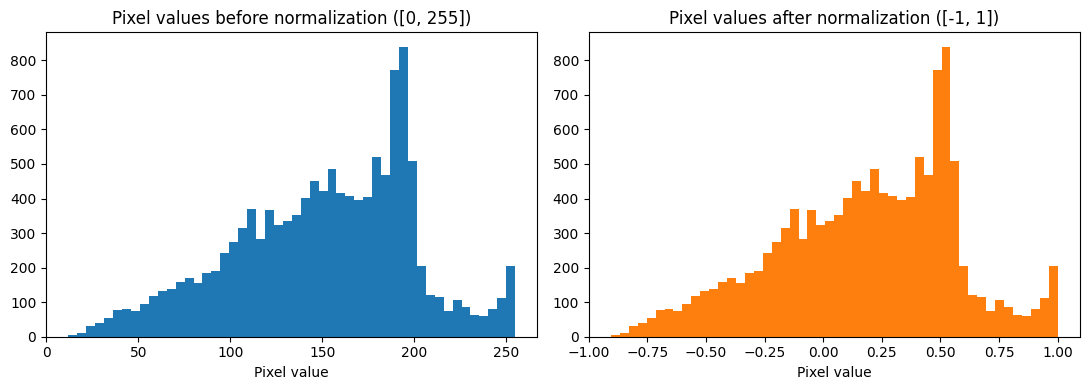

In [13]:
def normalize(img_uint8):
    """Scale [0, 255] uint8 image to [-1, 1] float32, matching the Generator's tanh output range."""
    return img_uint8.astype(np.float32) / 127.5 - 1.0

def denormalize(img_float):
    """Inverse of normalize(): scale [-1, 1] float32 back to [0, 255] uint8 for display/saving."""
    return np.clip(np.round((img_float + 1.0) * 127.5), 0, 255).astype(np.uint8)

_, demo_resized = load_and_resize(sample_rows.iloc[0]["filepath"])
demo_normalized = normalize(demo_resized)
demo_roundtrip = denormalize(demo_normalized)

print(f"Original dtype/range   : {demo_resized.dtype}, [{demo_resized.min()}, {demo_resized.max()}]")
print(f"Normalized dtype/range : {demo_normalized.dtype}, [{demo_normalized.min():.3f}, {demo_normalized.max():.3f}]")
print(f"Round-trip matches original: {np.array_equal(demo_resized, demo_roundtrip)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(demo_resized.ravel(), bins=50, color="#1f77b4")
axes[0].set_title("Pixel values before normalization ([0, 255])")
axes[0].set_xlabel("Pixel value")
axes[1].hist(demo_normalized.ravel(), bins=50, color="#ff7f0e")
axes[1].set_title("Pixel values after normalization ([-1, 1])")
axes[1].set_xlabel("Pixel value")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_normalization_histogram.png", dpi=150)
plt.show()


## 10. Data Augmentation Strategy (Preview)

### English

**Objective**

- Define and preview the augmentation strategy for `04_model_training.ipynb`: a random **horizontal flip** applied on-the-fly during training, with 50% probability per sample per epoch.

**Notes**

- Only horizontal flipping is used. Dog and cat faces have a canonical up/down orientation (eyes above nose/mouth, ears at top), so vertical flips or arbitrary rotations would produce anatomically implausible training examples and are deliberately excluded. A left-right flip preserves anatomical plausibility while still doubling the effective diversity of poses the Discriminator sees.
- Augmentation is applied **on-the-fly** in the training data pipeline rather than precomputed and saved to disk here, so every epoch sees a fresh, independent flip decision per image instead of a single fixed augmented copy — this preserves more effective diversity over many training epochs than baking in one static augmented version per image would.

**Output**

- A preview grid: original vs. horizontally-flipped, one example per species.

---

### Tiếng Việt

**Mục tiêu**

- Xác định và minh họa chiến lược augmentation cho `04_model_training.ipynb`: lật ngang (horizontal flip) ngẫu nhiên, áp dụng động lúc huấn luyện, với xác suất 50% cho mỗi ảnh ở mỗi epoch.

**Lưu ý**

- Chỉ dùng lật ngang. Mặt chó và mèo có hướng trên/dưới cố định theo giải phẫu (mắt phía trên mũi/miệng, tai ở trên cùng), nên lật dọc hay xoay tùy ý sẽ tạo ra các ví dụ huấn luyện phi thực tế về mặt giải phẫu, nên bị loại trừ có chủ đích. Lật trái-phải vẫn giữ được tính hợp lý về giải phẫu trong khi tăng gấp đôi số dáng ảnh hiệu dụng mà Discriminator quan sát được.
- Augmentation được áp dụng **động** trong pipeline dữ liệu lúc huấn luyện thay vì tính trước và lưu vào đĩa ở đây, để mỗi epoch có một quyết định lật độc lập, mới cho từng ảnh thay vì chỉ một bản augment cố định — cách này giữ được nhiều đa dạng hiệu dụng hơn qua nhiều epoch so với việc lưu cố định một bản augment tĩnh cho mỗi ảnh.

**Kết quả**

- Lưới minh họa: ảnh gốc so với ảnh đã lật ngang, một ví dụ cho mỗi loài.


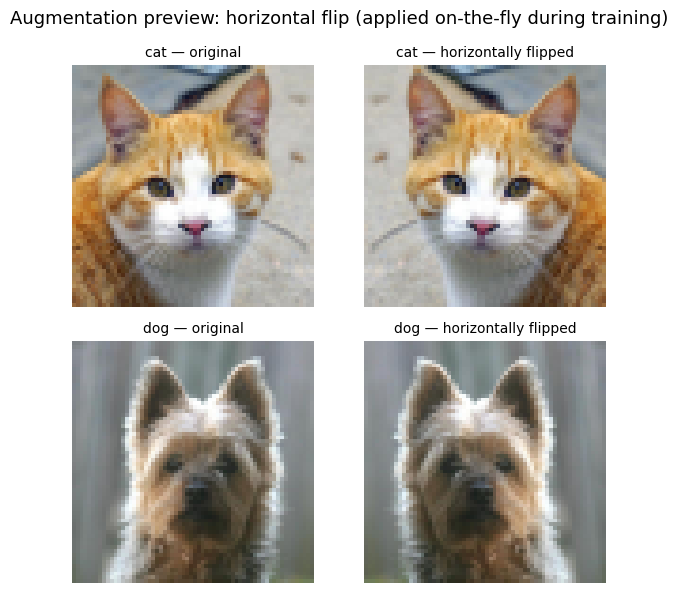

In [14]:
def random_horizontal_flip(img, p=0.5, rng=None):
    """Flip an HxWxC image left-right with probability p. Used on-the-fly in the training pipeline."""
    rng = rng or np.random
    if rng.random() < p:
        return np.fliplr(img)
    return img

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(6, 3 * len(sample_rows)))
axes = np.atleast_2d(axes)

for i, row in sample_rows.iterrows():
    _, resized = load_and_resize(row["filepath"])
    flipped = np.fliplr(resized)
    axes[i, 0].imshow(resized)
    axes[i, 0].set_title(f"{row['species']} — original", fontsize=10)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(flipped)
    axes[i, 1].set_title(f"{row['species']} — horizontally flipped", fontsize=10)
    axes[i, 1].axis("off")

fig.suptitle("Augmentation preview: horizontal flip (applied on-the-fly during training)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_augmentation_preview.png", dpi=150)
plt.show()


## 11. Process and Export All Kept Images and Manifests

### English

**Objective**

- Apply the resize step (Section 8) to every image in `train_df` and `val_df`, saving the 64×64 result as a PNG under `data/processed/images_64/`.
- Write `data/processed/train_manifest_64.csv` and `data/processed/val_manifest_64.csv` (columns: `filepath`, `species`, `split`), and `data/processed/removed_images_log_64.csv` recording every removed image and its reason, for traceability.

**Notes**

- Files are skipped if already present with the expected size, so this step is safe to re-run.

---

### Tiếng Việt

**Mục tiêu**

- Áp dụng bước resize (Mục 8) cho toàn bộ ảnh trong `train_df` và `val_df`, lưu kết quả 64×64 dưới dạng PNG vào `data/processed/images_64/`.
- Ghi `data/processed/train_manifest_64.csv` và `data/processed/val_manifest_64.csv` (cột: `filepath`, `species`, `split`), và `data/processed/removed_images_log_64.csv` ghi lại toàn bộ ảnh bị loại bỏ cùng lý do, phục vụ truy vết sau này.

**Lưu ý**

- Các file đã tồn tại với đúng kích thước sẽ được bỏ qua, nên bước này có thể chạy lại an toàn.


In [15]:
def export_split(df, split_name):
    out_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Exporting {split_name}"):
        src_path = PROJECT_ROOT / row["filepath"]
        dst_path = IMAGES_64_DIR / Path(row["filepath"]).name

        needs_write = True
        if dst_path.exists():
            existing = cv2.imread(str(dst_path))
            needs_write = existing is None or existing.shape[:2] != TARGET_SIZE[::-1]

        if needs_write:
            _, resized = load_and_resize(row["filepath"])
            Image.fromarray(resized).save(dst_path)

        out_rows.append({
            "filepath": str(dst_path.relative_to(PROJECT_ROOT)),
            "species": row["species"],
            "split": split_name,
        })
    return pd.DataFrame(out_rows)

train_out = export_split(train_df, "train")
val_out = export_split(val_df, "val")

train_out.to_csv(DATA_PROCESSED / "train_manifest_64.csv", index=False)
val_out.to_csv(DATA_PROCESSED / "val_manifest_64.csv", index=False)

removed_log = features[features["removal_reason"].notna()][["filepath", "species", "removal_reason"]]
removed_log.to_csv(DATA_PROCESSED / "removed_images_log_64.csv", index=False)

print(f"Wrote {len(train_out)} rows to train_manifest_64.csv")
print(f"Wrote {len(val_out)} rows to val_manifest_64.csv")
print(f"Wrote {len(removed_log)} rows to removed_images_log_64.csv")


Exporting train:   0%|          | 0/9950 [00:00<?, ?it/s]

Exporting val:   0%|          | 0/866 [00:00<?, ?it/s]

Wrote 9950 rows to train_manifest_64.csv
Wrote 866 rows to val_manifest_64.csv
Wrote 76 rows to removed_images_log_64.csv


## 12. Final Sanity Checks

### English

**Objective**

- Confirm every exported image is actually readable and exactly 64×64.
- Visualize a sample grid from the final training set, by species, to confirm the end-to-end pipeline produced correct, undistorted images.
- Report final split/species counts.

**Output**

- A sample grid and a final counts table.

---

### Tiếng Việt

**Mục tiêu**

- Xác nhận mọi ảnh đã xuất đều đọc được và có đúng kích thước 64×64.
- Trực quan hóa một lưới ảnh mẫu từ tập train cuối cùng, theo từng loài, để xác nhận toàn bộ pipeline tạo ra ảnh đúng, không bị méo.
- Báo cáo số lượng cuối cùng theo tập/loài.

**Kết quả**

- Lưới ảnh mẫu và bảng số lượng cuối cùng.


In [16]:
bad_files = []
for fp in tqdm(pd.concat([train_out["filepath"], val_out["filepath"]]), desc="Verifying exported images"):
    img = cv2.imread(str(PROJECT_ROOT / fp))
    if img is None or img.shape[:2] != TARGET_SIZE[::-1]:
        bad_files.append(fp)

if bad_files:
    print(f"WARNING: {len(bad_files)} exported image(s) failed verification: {bad_files[:10]}")
else:
    print("All exported images are readable and exactly 64x64.")


Verifying exported images:   0%|          | 0/10816 [00:00<?, ?it/s]

All exported images are readable and exactly 64x64.


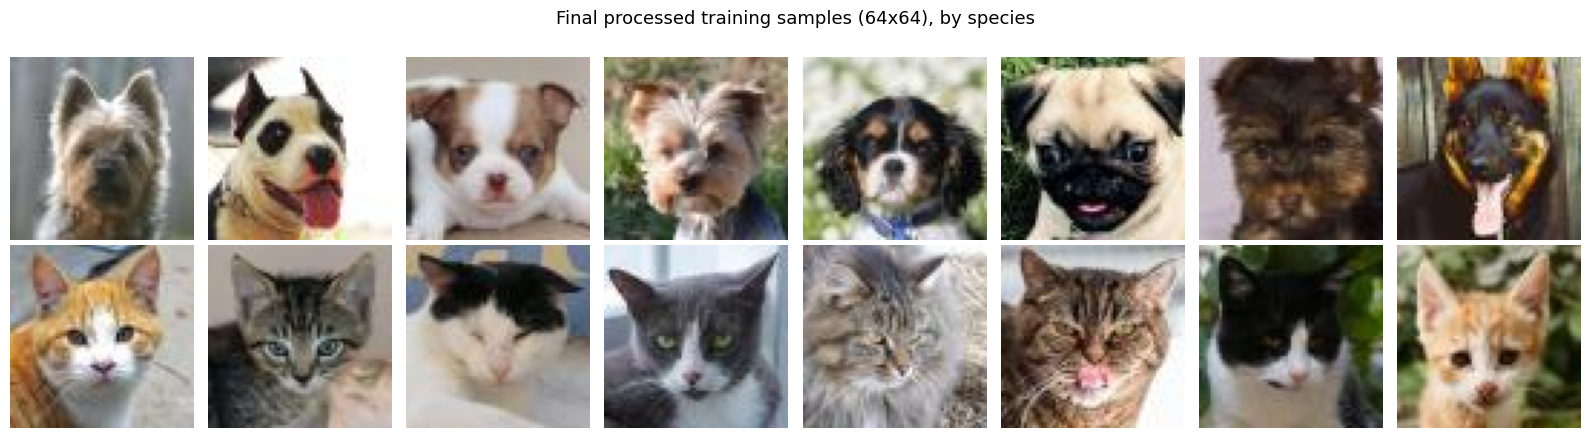


Final counts:
split  species
train  cat        5144
       dog        4806
val    cat         448
       dog         418
dtype: int64


In [17]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))

for row_i, species in enumerate(["dog", "cat"]):
    species_sample = train_out[train_out["species"] == species].sample(8, random_state=RANDOM_SEED)
    for col_i, (_, r) in enumerate(species_sample.iterrows()):
        img = PILImage.open(PROJECT_ROOT / r["filepath"])
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].axis("off")
        if col_i == 0:
            axes[row_i, col_i].set_ylabel(species)

fig.suptitle("Final processed training samples (64x64), by species", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_final_sample_grid.png", dpi=150)
plt.show()

final_counts = pd.concat([train_out.assign(split="train"), val_out.assign(split="val")]).groupby(["split", "species"]).size()
print("\nFinal counts:")
print(final_counts)


## Summary

### English

**Completed**

- Recomputed perceptual hash, grayscale standard deviation, and blur variance for all 10,892 validated images.
- Detected and removed near-blank/corrupted frames using a combined low-standard-deviation-and-low-blur-variance rule, visually confirmed before removal.
- Detected and removed exact- and near-duplicate images via perceptual hashing and connected-components grouping, keeping the sharpest image per group; duplication was confirmed to concentrate almost entirely in the cat class, consistent with `02_eda.ipynb`'s findings.
- Produced a stratified 92/8 train/validation split by species, sized to support the memorization check planned in `05_evaluation_report.ipynb` rather than model selection.
- Resized every kept image from 512×512 to 64×64 using area interpolation, and defined (with demonstration) the `[-1, 1]` normalization applied on-the-fly at training time.
- Defined and previewed the augmentation strategy — on-the-fly random horizontal flip only, since vertical flips/rotations would be anatomically implausible for animal faces.
- Exported `train_manifest_64.csv`, `val_manifest_64.csv`, `removed_images_log_64.csv`, and all processed 64×64 images, then verified every exported file is readable and correctly sized.

**Implications for Model Training (`04_model_training.ipynb`)**

- Load images from `train_manifest_64.csv` / `val_manifest_64.csv`, apply `normalize()` and `random_horizontal_flip()` on-the-fly in the `tf.data` input pipeline.
- Use the `species` column directly as the conditioning label for both Generator and Discriminator.

**Next Notebook**

- `04_model_training.ipynb` — trains the conditional DCGAN with the Sobel auxiliary channel on this processed 64×64 dataset, on Google Colab (GPU).

---

### Tiếng Việt

**Đã hoàn thành**

- Tính lại perceptual hash, độ lệch chuẩn grayscale, và blur variance cho toàn bộ 10.892 ảnh đã qua kiểm tra hợp lệ.
- Phát hiện và loại bỏ các khung hình gần như trống/hỏng bằng quy tắc kết hợp độ lệch chuẩn thấp và blur variance thấp, đã xác nhận trực quan trước khi loại bỏ.
- Phát hiện và loại bỏ ảnh trùng lặp chính xác và trùng lặp gần qua perceptual hashing và gom nhóm connected-components, giữ lại ảnh sắc nét nhất mỗi nhóm; xác nhận trùng lặp tập trung gần như hoàn toàn ở lớp mèo, khớp với phát hiện của `02_eda.ipynb`.
- Tạo tập train/validation phân tầng theo loài với tỉ lệ 92/8, kích thước được chọn để phục vụ kiểm tra memorization dự kiến ở `05_evaluation_report.ipynb` chứ không phải để chọn mô hình.
- Resize mọi ảnh được giữ lại từ 512×512 xuống 64×64 bằng nội suy area, và xác định (kèm minh họa) việc chuẩn hóa `[-1, 1]` áp dụng động lúc huấn luyện.
- Xác định và minh họa chiến lược augmentation — chỉ lật ngang ngẫu nhiên áp dụng động, vì lật dọc/xoay sẽ phi thực tế về giải phẫu đối với mặt động vật.
- Xuất `train_manifest_64.csv`, `val_manifest_64.csv`, `removed_images_log_64.csv`, và toàn bộ ảnh đã xử lý 64×64, sau đó xác nhận mọi file xuất ra đều đọc được và đúng kích thước.

**Ý nghĩa đối với huấn luyện mô hình (`04_model_training.ipynb`)**

- Tải ảnh từ `train_manifest_64.csv` / `val_manifest_64.csv`, áp dụng `normalize()` và `random_horizontal_flip()` động trong pipeline dữ liệu `tf.data`.
- Dùng trực tiếp cột `species` làm nhãn điều kiện cho cả Generator và Discriminator.

**Notebook tiếp theo**

- `04_model_training.ipynb` — huấn luyện conditional DCGAN với kênh phụ Sobel trên tập dữ liệu 64×64 đã xử lý này, chạy trên Google Colab (GPU).
